# DICOM Tag Snapshot Descriptive Analysis

This notebook profiles `tests/data/dicom_tags_snapshot.ndjson` end-to-end: coverage, missingness, cardinality, modality/geometry distributions, and quality flags.

In [1]:
from pathlib import Path
import os

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR if NOTEBOOK_DIR.name == "IMPERANDI" else NOTEBOOK_DIR.parent
if Path.cwd() != PROJECT_ROOT:
    os.chdir(PROJECT_ROOT)

SNAPSHOT_PATH = Path("tests/data/dicom_tags_snapshot.ndjson")
if not SNAPSHOT_PATH.exists():
    raise FileNotFoundError(f"Snapshot file not found: {SNAPSHOT_PATH.resolve()}")

print("Notebook dir :", NOTEBOOK_DIR)
print("Project root :", PROJECT_ROOT)
print("Snapshot path:", SNAPSHOT_PATH.resolve())

Notebook dir : /mnt/Data/Code/IMPERANDI/dashboards
Project root : /mnt/Data/Code/IMPERANDI
Snapshot path: /mnt/Data/Code/IMPERANDI/tests/data/dicom_tags_snapshot.ndjson


In [2]:
import ast
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 100)

## 1) Load and normalize snapshot

In [3]:
records = []
with SNAPSHOT_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        records.append(json.loads(line))

df_raw = pd.DataFrame(records)
if "tags" not in df_raw.columns:
    raise ValueError("Expected a 'tags' column with nested dictionaries in snapshot file")

tags_df = pd.json_normalize(df_raw["tags"]).copy()
df = pd.concat([df_raw.drop(columns=["tags"]), tags_df], axis=1)

meta_cols = [c for c in ["dicom_path", "_scan_root", "_relative_path", "snapshot_seed", "snapshot_index"] if c in df.columns]
tag_cols = [c for c in df.columns if c not in meta_cols]

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,} (metadata={len(meta_cols)}, tags={len(tag_cols)})")
print(f"Unique dicom_path: {df['dicom_path'].nunique() if 'dicom_path' in df.columns else 'n/a'}")
print(f"Unique _scan_root: {df['_scan_root'].nunique() if '_scan_root' in df.columns else 'n/a'}")
print(f"snapshot_seed values: {sorted(df['snapshot_seed'].dropna().unique().tolist()) if 'snapshot_seed' in df.columns else 'n/a'}")

Rows: 2
Columns: 43 (metadata=5, tags=38)
Unique dicom_path: 2
Unique _scan_root: 1
snapshot_seed values: [42]


In [4]:
display(pd.DataFrame({
    "metadata_columns": pd.Series(meta_cols),
    "tag_columns": pd.Series(tag_cols[: max(len(meta_cols), len(tag_cols))])
}))
display(df.head(3))

,metadata_columns,tag_columns
0,dicom_path,ImageType
1,_scan_root,SOPClassUID
2,_relative_path,SOPInstanceUID
3,snapshot_seed,StudyDate
4,snapshot_index,AcquisitionDate
5,NaN,StudyTime
6,NaN,AcquisitionTime
7,NaN,AccessionNumber
8,NaN,Modality
9,NaN,InstitutionName


,dicom_path,_scan_root,_relative_path,snapshot_seed,snapshot_index,ImageType,SOPClassUID,SOPInstanceUID,StudyDate,AcquisitionDate,StudyTime,AcquisitionTime,AccessionNumber,Modality,InstitutionName,ReferringPhysicianName,PatientName,PatientID,PatientBirthDate,PatientSex,SliceThickness,SpacingBetweenSlices,StudyInstanceUID,SeriesInstanceUID,StudyID,SeriesNumber,InstanceNumber,ImagePositionPatient,ImageOrientationPatient,SamplesPerPixel,PhotometricInterpretation,Rows,Columns,PixelSpacing,BitsAllocated,BitsStored,HighBit,PixelRepresentation,WindowCenter,WindowWidth,RescaleIntercept,RescaleSlope,WindowCenterWidthExplanation
0,tests/data/IRCAD_DICOM/3Dircadb1.2/exam/image_0,tests/data/IRCAD_DICOM,3Dircadb1.2/exam/image_0,42,0,"['ORIGINAL', 'PRIMARY']",1.2.840.10008.5.1.4.1.1.2,1.2.826.0.1.3680043.2.1125.4828972417509620516...,20090527,20090527,125115,125115,,CT,IRCAD,,liver_02^patient,,20090527,M,1.6000000238418579,1.6000000238418579,1.2.826.0.1.3680043.2.1125.5998964760887913365...,1.2.826.0.1.3680043.2.1125.3253956498577534545...,,NaN,0,"[0, 0, 0]","[1, 0, 0, 0, 1, 0]",1,MONOCHROME2,512,512,"[0.782000005245209, 0.782000005245209]",16,16,15,1,0,0,0,1,
1,tests/data/IRCAD_DICOM/3Dircadb1.1/exam/image_0,tests/data/IRCAD_DICOM,3Dircadb1.1/exam/image_0,42,1,"['ORIGINAL', 'PRIMARY']",1.2.840.10008.5.1.4.1.1.2,1.2.826.0.1.3680043.2.1125.3117066890503337486...,20090527,20090527,125005,125005,,CT,IRCAD,,liver_01^patient,,20090527,M,1.6000000238418579,1.6000000238418579,1.2.826.0.1.3680043.2.1125.6907248010745639067...,1.2.826.0.1.3680043.2.1125.9647753419956608505...,,NaN,0,"[0, 0, 0]","[1, 0, 0, 0, 1, 0]",1,MONOCHROME2,512,512,"[0.569999992847443, 0.569999992847443]",16,16,15,1,0,0,0,1,


## 2) Schema and type helpers

In [5]:
def to_numeric_safe(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

def parse_pixel_spacing(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return (np.nan, np.nan)
    if isinstance(value, (list, tuple)) and len(value) >= 2:
        try:
            return float(value[0]), float(value[1])
        except Exception:
            return (np.nan, np.nan)

    s = str(value).strip()
    if not s:
        return (np.nan, np.nan)

    parsed = None
    try:
        parsed = ast.literal_eval(s)
    except Exception:
        parsed = None

    if isinstance(parsed, (list, tuple)) and len(parsed) >= 2:
        try:
            return float(parsed[0]), float(parsed[1])
        except Exception:
            return (np.nan, np.nan)

    cleaned = s.replace("[", "").replace("]", "").replace("(", "").replace(")", "")
    parts = [p.strip() for p in cleaned.replace(";", ",").split(",") if p.strip()]
    if len(parts) >= 2:
        try:
            return float(parts[0]), float(parts[1])
        except Exception:
            return (np.nan, np.nan)

    return (np.nan, np.nan)

for col in ["Rows", "Columns", "SliceThickness", "SpacingBetweenSlices", "RescaleSlope", "RescaleIntercept"]:
    if col in df.columns:
        df[col + "_num"] = to_numeric_safe(df[col])

if "PixelSpacing" in df.columns:
    xy = df["PixelSpacing"].apply(parse_pixel_spacing)
    df["PixelSpacing_X"] = xy.apply(lambda t: t[0])
    df["PixelSpacing_Y"] = xy.apply(lambda t: t[1])

dtype_df = df.dtypes.astype(str).reset_index()
dtype_df.columns = ["column", "dtype"]
display(dtype_df.sort_values(["dtype", "column"]).head(120))

,column,dtype
49,PixelSpacing_X,float64
50,PixelSpacing_Y,float64
25,SeriesNumber,float64
45,SliceThickness_num,float64
46,SpacingBetweenSlices_num,float64
44,Columns_num,int64
48,RescaleIntercept_num,int64
47,RescaleSlope_num,int64
43,Rows_num,int64
4,snapshot_index,int64


## 3) Coverage and missingness

In [6]:
coverage = pd.DataFrame({
    "column": df.columns,
    "present_count": [df[c].notna().sum() for c in df.columns],
})
coverage["missing_count"] = len(df) - coverage["present_count"]
coverage["present_pct"] = 100.0 * coverage["present_count"] / max(len(df), 1)
coverage = coverage.sort_values("present_pct", ascending=False).reset_index(drop=True)

display(coverage.head(20))

low_coverage = coverage[coverage["present_pct"] < 20].copy()
print(f"Columns with <20% coverage: {len(low_coverage)}")
display(low_coverage.head(50))

,column,present_count,missing_count,present_pct
0,dicom_path,2,0,100.0
1,_scan_root,2,0,100.0
2,_relative_path,2,0,100.0
3,snapshot_seed,2,0,100.0
4,snapshot_index,2,0,100.0
5,ImageType,2,0,100.0
6,SOPClassUID,2,0,100.0
7,SOPInstanceUID,2,0,100.0
8,StudyDate,2,0,100.0
9,AcquisitionDate,2,0,100.0


Columns with <20% coverage: 1


,column,present_count,missing_count,present_pct
50,SeriesNumber,0,2,0.0


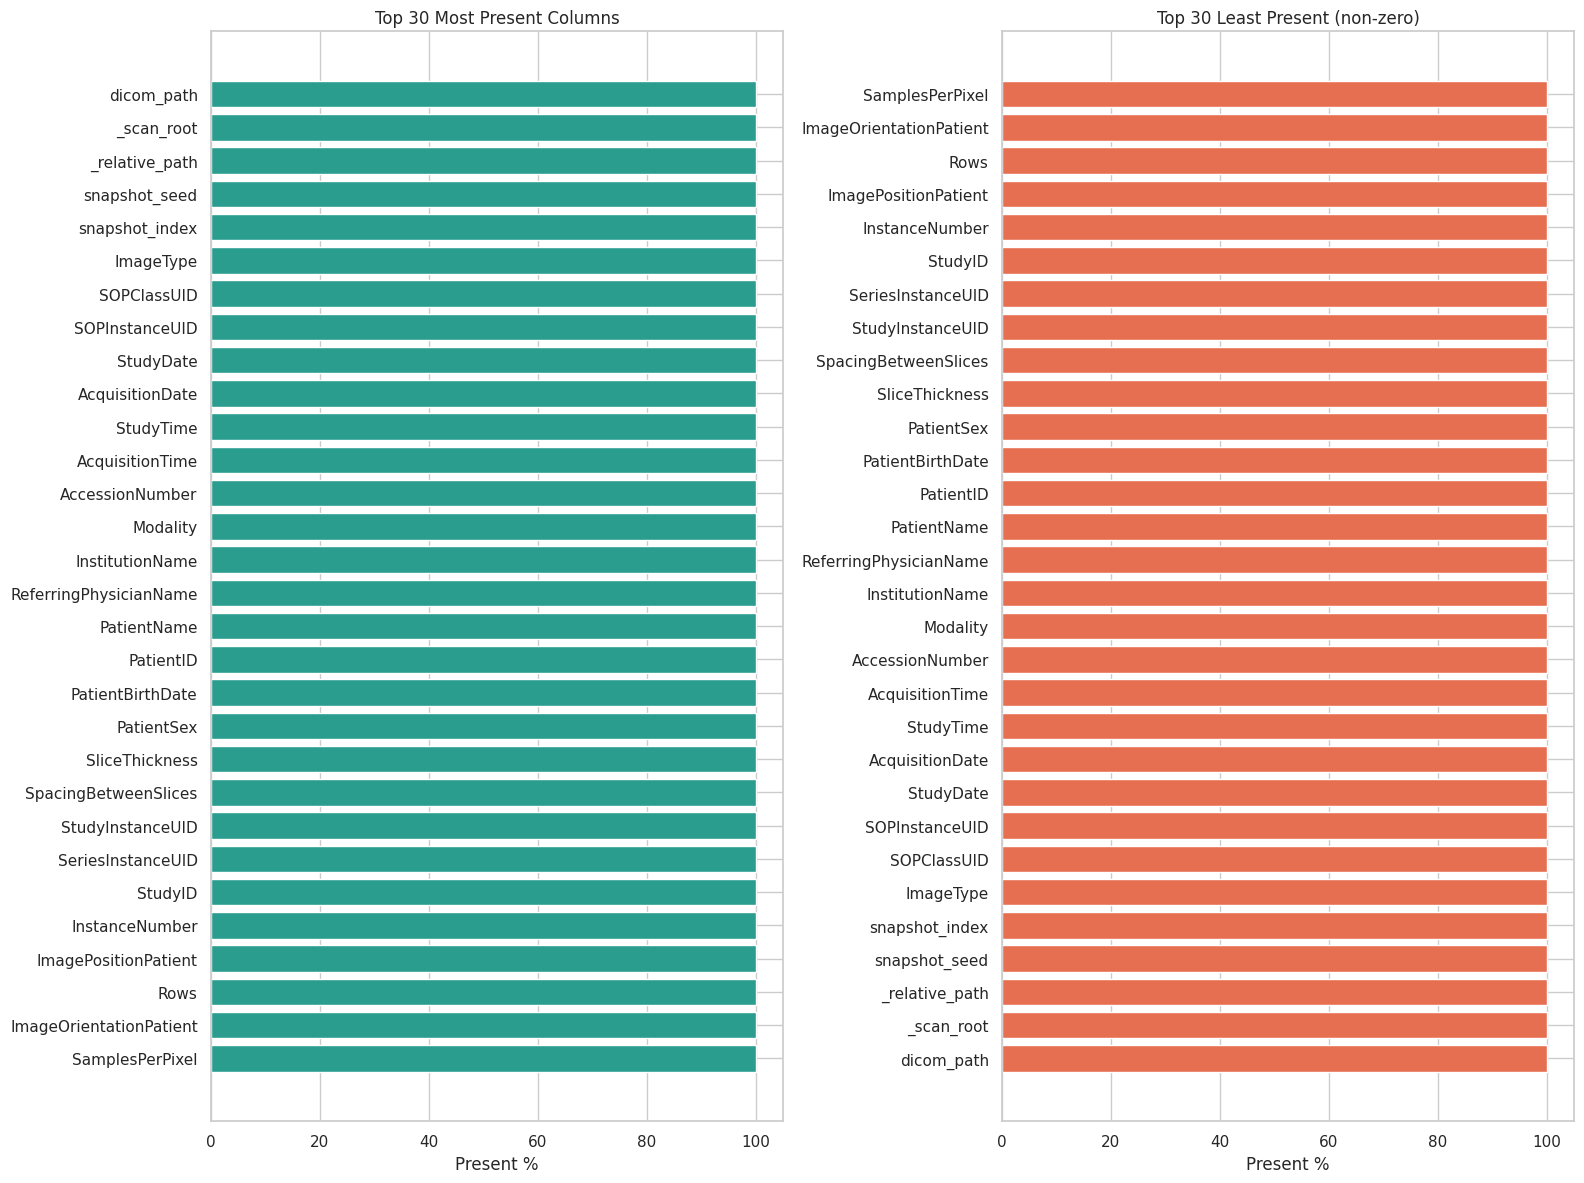

In [7]:
top_present = coverage.head(30).iloc[::-1]
top_least_nonzero = coverage[(coverage["present_count"] > 0)].sort_values("present_pct", ascending=True).head(30)

fig, axes = plt.subplots(1, 2, figsize=(16, 12))
axes[0].barh(top_present["column"], top_present["present_pct"], color="#2a9d8f")
axes[0].set_title("Top 30 Most Present Columns")
axes[0].set_xlabel("Present %")

axes[1].barh(top_least_nonzero["column"], top_least_nonzero["present_pct"], color="#e76f51")
axes[1].set_title("Top 30 Least Present (non-zero)")
axes[1].set_xlabel("Present %")

plt.tight_layout()
plt.show()

## 4) Cardinality and key value profiles

,column,n_unique,dtype
0,dicom_path,2,str
1,_relative_path,2,str
2,snapshot_index,2,int64
3,PatientName,2,str
4,SOPInstanceUID,2,str
5,StudyTime,2,str
6,AcquisitionTime,2,str
7,PixelSpacing_Y,2,float64
8,PixelSpacing,2,str
9,SeriesInstanceUID,2,str


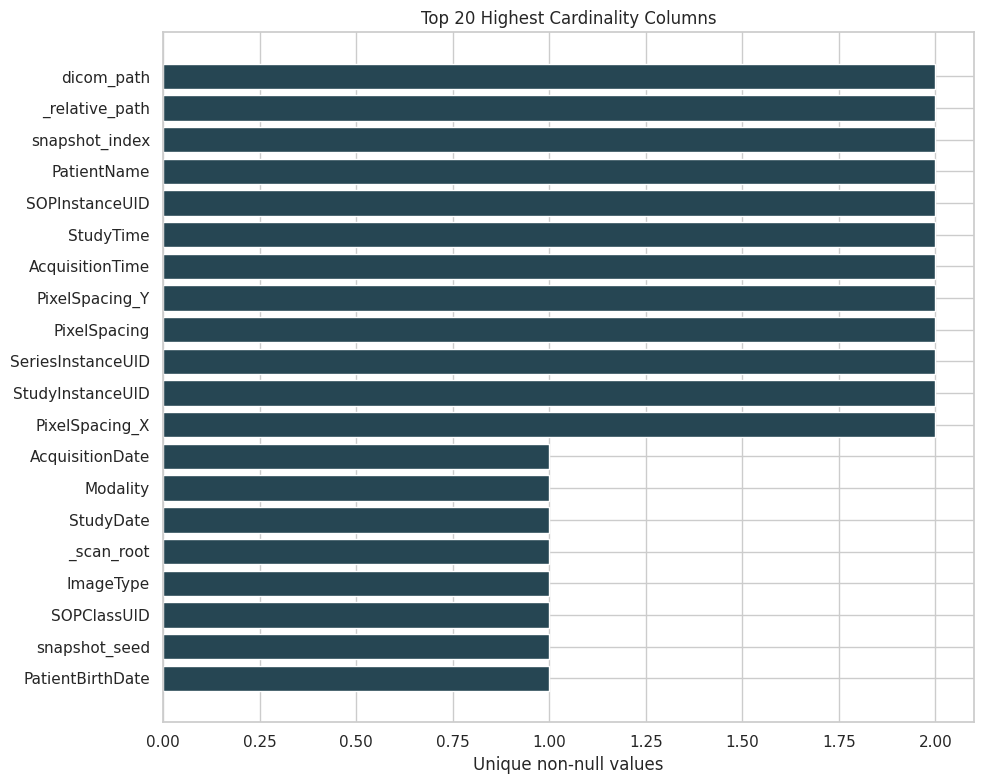

In [8]:
cardinality = pd.DataFrame({
    "column": df.columns,
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
    "dtype": [str(df[c].dtype) for c in df.columns],
})
cardinality = cardinality.sort_values("n_unique", ascending=False).reset_index(drop=True)
display(cardinality.head(30))

plt.figure(figsize=(10, 8))
tmp = cardinality.head(20).iloc[::-1]
plt.barh(tmp["column"], tmp["n_unique"], color="#264653")
plt.title("Top 20 Highest Cardinality Columns")
plt.xlabel("Unique non-null values")
plt.tight_layout()
plt.show()


Top values for Modality (n=1 shown):


,count
Modality,
CT,2


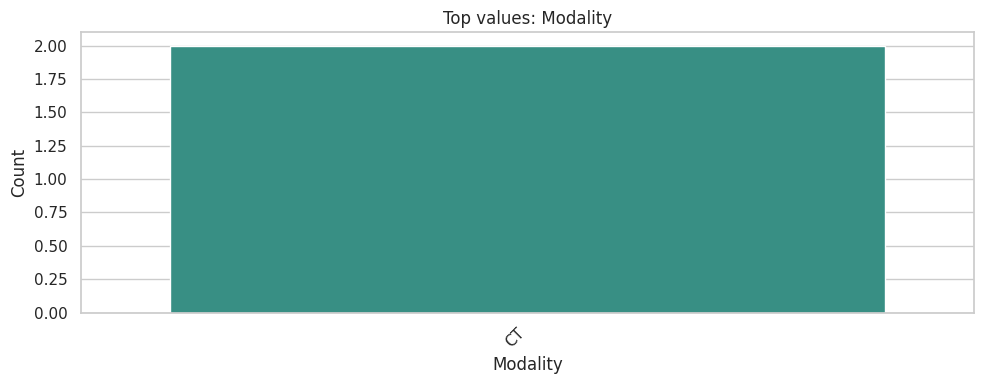


Top values for ImageType (n=1 shown):


,count
ImageType,
"['ORIGINAL', 'PRIMARY']",2


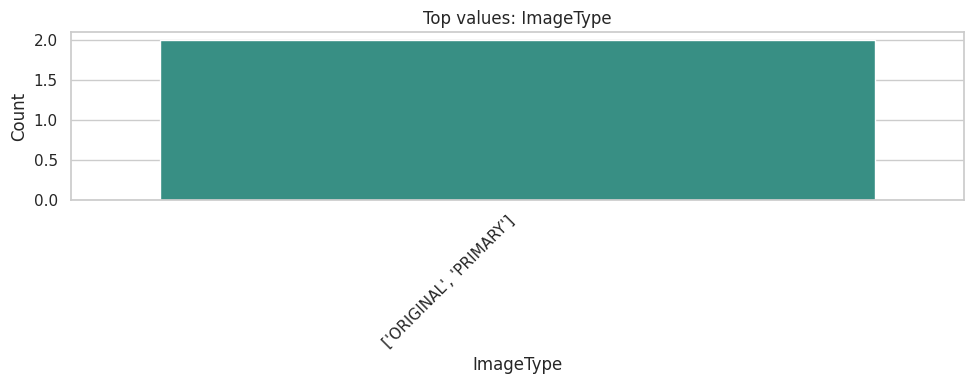


Top values for PhotometricInterpretation (n=1 shown):


,count
PhotometricInterpretation,
MONOCHROME2,2


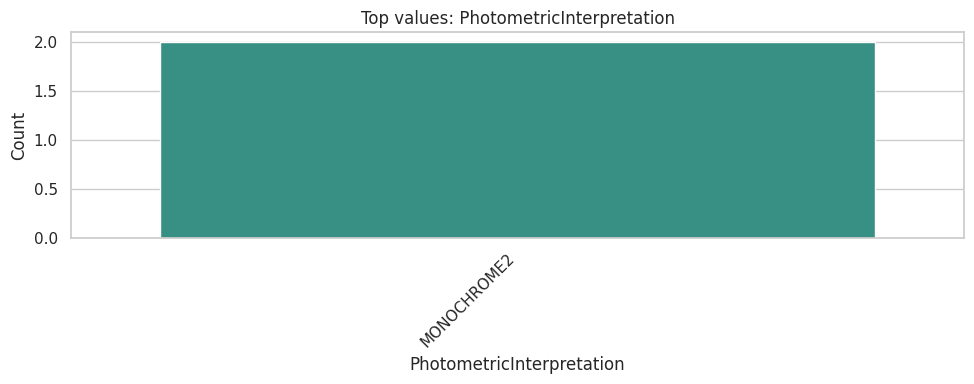


Top values for PatientSex (n=1 shown):


,count
PatientSex,
M,2


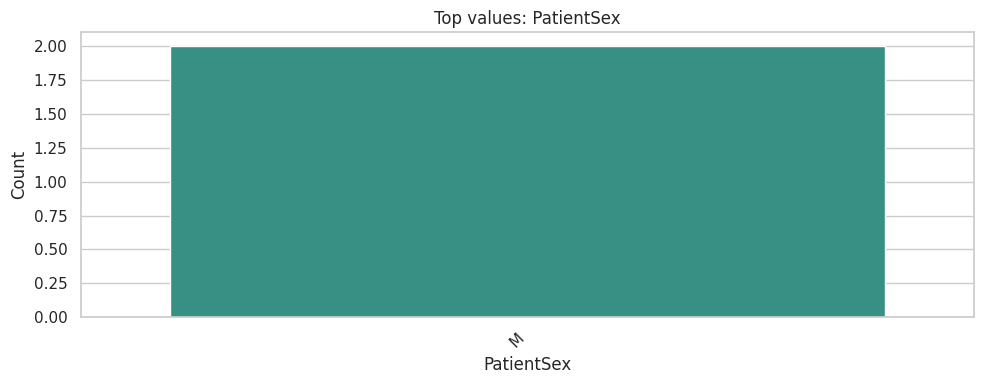


Top values for InstitutionName (n=1 shown):


,count
InstitutionName,
IRCAD,2


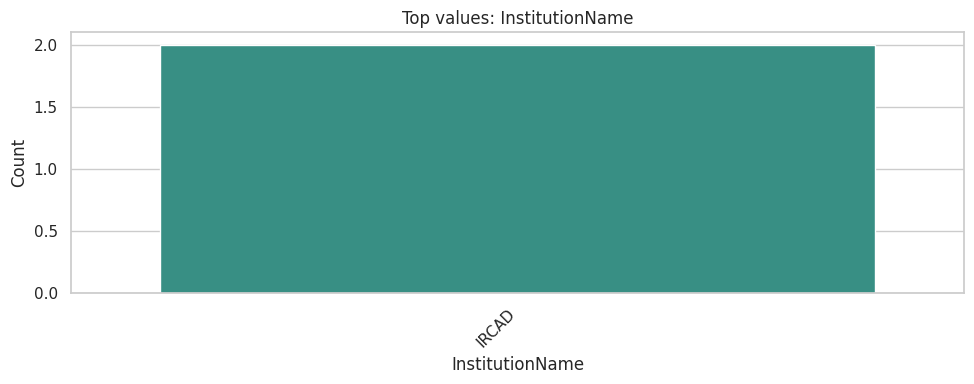

In [9]:
key_cols = ["Modality", "ImageType", "PhotometricInterpretation", "PatientSex", "InstitutionName"]
for col in key_cols:
    if col not in df.columns:
        print(f"{col}: column not present")
        continue

    counts = df[col].astype(str).replace("nan", np.nan).dropna().value_counts().head(20)
    print(f"\nTop values for {col} (n={len(counts)} shown):")
    display(counts.to_frame("count"))

    plt.figure(figsize=(10, 4))
    sns.barplot(x=counts.index.astype(str), y=counts.values, color="#2a9d8f")
    plt.title(f"Top values: {col}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

## 5) Geometry and acquisition descriptives

,count,mean,std,min,1%,5%,50%,95%,99%,max
Rows_num,2.0,512.000,0.000000,512.00,512.00000,512.0000,512.000,512.0000,512.00000,512.000
Columns_num,2.0,512.000,0.000000,512.00,512.00000,512.0000,512.000,512.0000,512.00000,512.000
SliceThickness_num,2.0,1.600,0.000000,1.60,1.60000,1.6000,1.600,1.6000,1.60000,1.600
PixelSpacing_X,2.0,0.676,0.149907,0.57,0.57212,0.5806,0.676,0.7714,0.77988,0.782
PixelSpacing_Y,2.0,0.676,0.149907,0.57,0.57212,0.5806,0.676,0.7714,0.77988,0.782


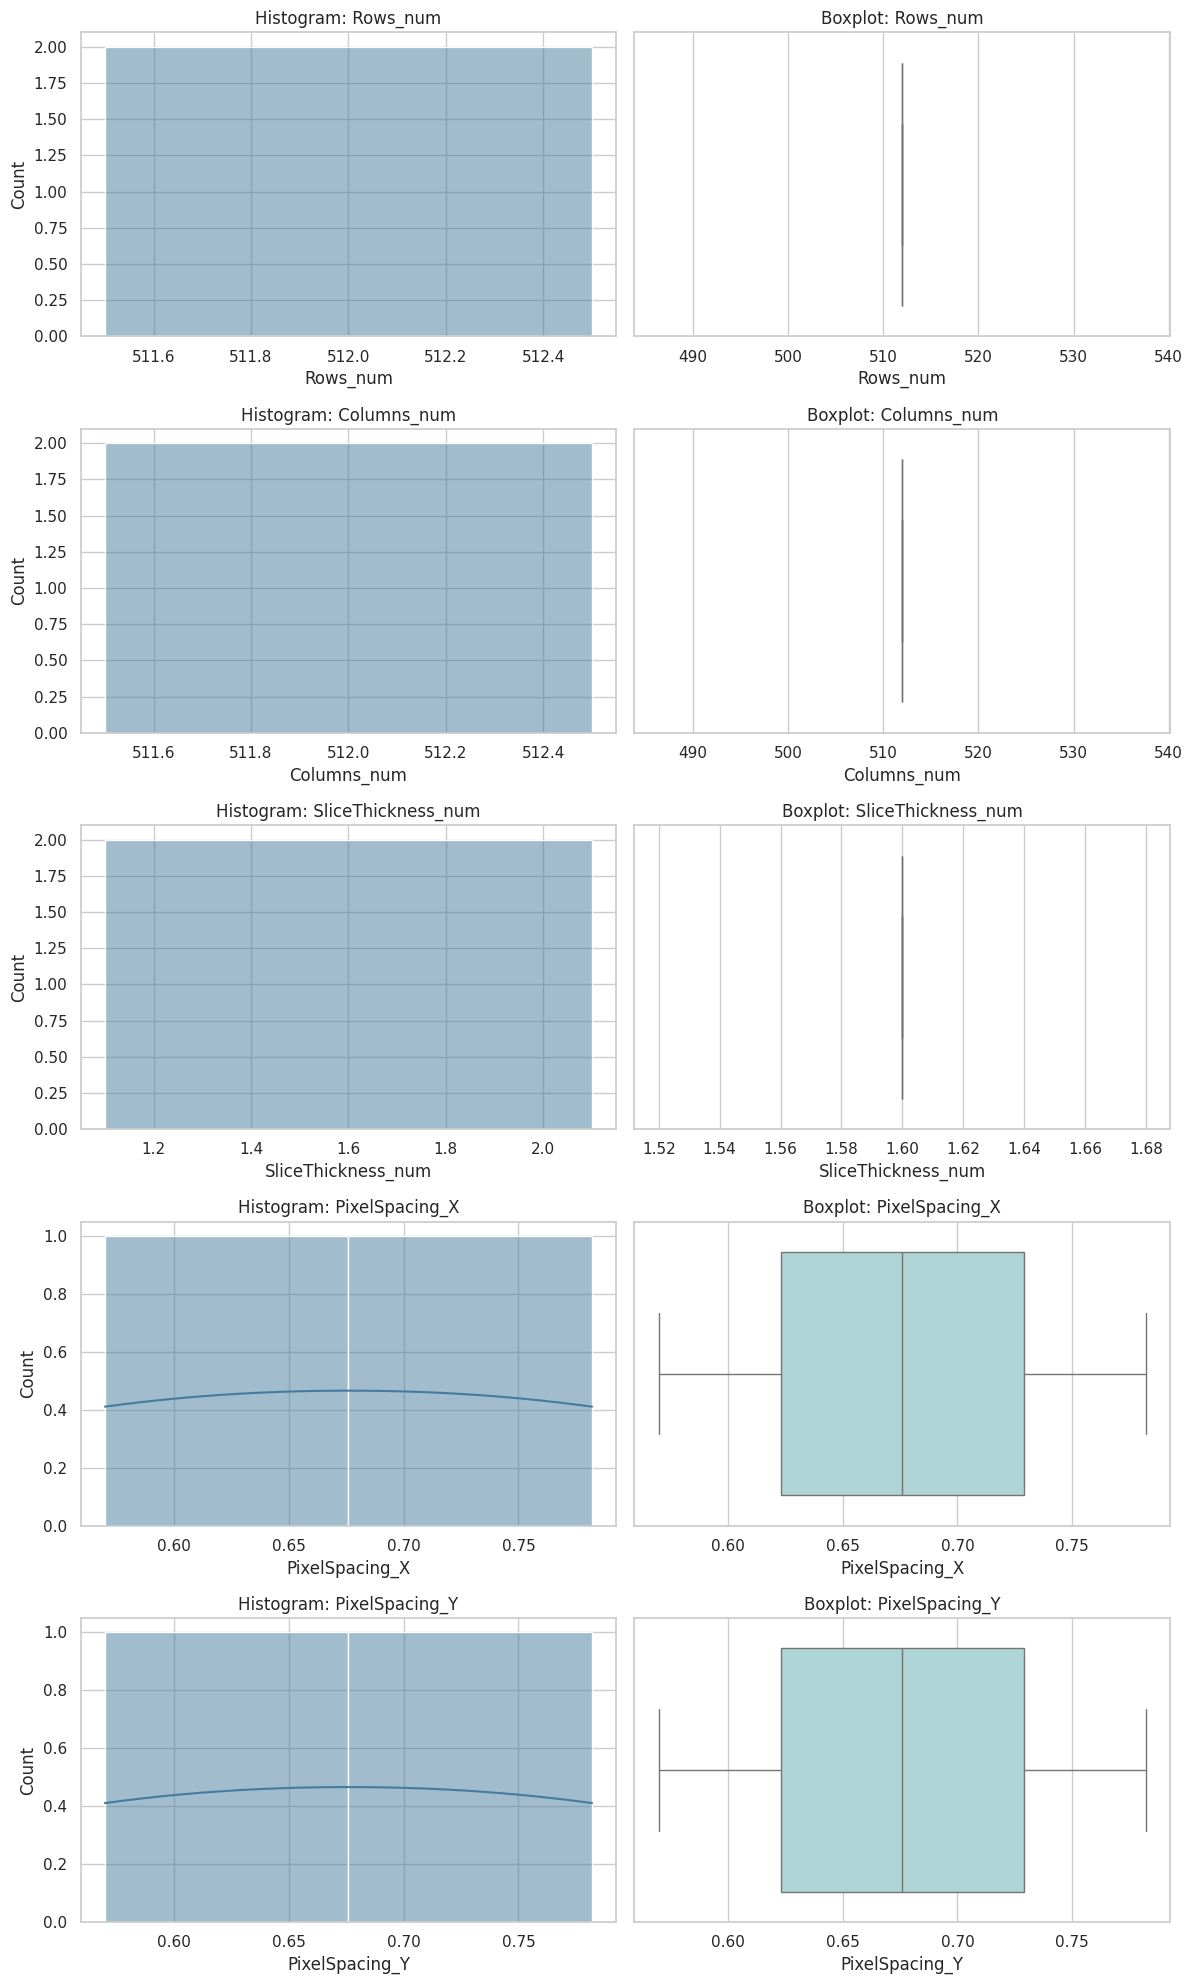

In [10]:
geom_cols = ["Rows_num", "Columns_num", "SliceThickness_num", "PixelSpacing_X", "PixelSpacing_Y"]
geom_cols = [c for c in geom_cols if c in df.columns]
if geom_cols:
    display(df[geom_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

    n = len(geom_cols)
    fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
    if n == 1:
        axes = np.array([axes])

    for i, col in enumerate(geom_cols):
        sns.histplot(df[col], kde=True, ax=axes[i, 0], color="#457b9d")
        axes[i, 0].set_title(f"Histogram: {col}")

        sns.boxplot(x=df[col], ax=axes[i, 1], color="#a8dadc")
        axes[i, 1].set_title(f"Boxplot: {col}")

    plt.tight_layout()
    plt.show()
else:
    print("No geometry columns available after parsing.")

In [11]:
if "Modality" in df.columns and "Rows_num" in df.columns and "Columns_num" in df.columns:
    modality_geom = df.groupby("Modality")[["Rows_num", "Columns_num"]].agg(["count", "mean", "median", "min", "max"])
    display(modality_geom)
else:
    print("Modality/Rows/Columns columns not fully available for cross-tab summary.")

Rows_num                         Columns_num                        
            count   mean median  min  max       count   mean median  min  max
Modality                                                                     
CT              2  512.0  512.0  512  512           2  512.0  512.0  512  512

## 6) Snapshot diagnostics

In [12]:
if "snapshot_seed" in df.columns:
    seeds = sorted(df["snapshot_seed"].dropna().unique().tolist())
    print("snapshot_seed values:", seeds)

if "dicom_path" in df.columns:
    dup_count = int(df["dicom_path"].duplicated().sum())
    print("Duplicate dicom_path rows:", dup_count)

if "_scan_root" in df.columns:
    display(df["_scan_root"].value_counts().head(20).to_frame("count"))

if "_relative_path" in df.columns:
    rel_first = df["_relative_path"].fillna("").astype(str).str.split("/").str[0]
    display(rel_first.value_counts().head(20).to_frame("count").rename_axis("first_path_segment"))

snapshot_seed values: [42]
Duplicate dicom_path rows: 0


,count
_scan_root,
tests/data/IRCAD_DICOM,2


,count
first_path_segment,
3Dircadb1.2,1
3Dircadb1.1,1


## 7) Data quality findings (QC digest)

In [13]:
critical = ["PatientID", "StudyInstanceUID", "SeriesInstanceUID", "SOPInstanceUID", "Modality"]
qc_rows = []
for c in critical:
    if c in df.columns:
        missing = int(df[c].isna().sum())
        qc_rows.append({"metric": f"missing_{c}", "value": missing, "pct": 100.0 * missing / max(len(df), 1)})
    else:
        qc_rows.append({"metric": f"missing_{c}", "value": "column_absent", "pct": np.nan})

for col in ["Rows_num", "Columns_num", "SliceThickness_num", "PixelSpacing_X", "PixelSpacing_Y"]:
    if col not in df.columns:
        continue
    s = df[col].dropna()
    if len(s) < 4:
        qc_rows.append({"metric": f"outliers_{col}", "value": 0, "pct": 0.0})
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = int(((df[col] < lo) | (df[col] > hi)).sum())
    qc_rows.append({"metric": f"outliers_{col}", "value": outliers, "pct": 100.0 * outliers / max(len(df), 1)})

high_card_cols = cardinality[cardinality["n_unique"] > 0.8 * len(df)]
qc_rows.append({"metric": "high_cardinality_columns_gt_80pct_rows", "value": int(len(high_card_cols)), "pct": np.nan})

qc_digest = pd.DataFrame(qc_rows)
display(qc_digest)

if len(high_card_cols) > 0:
    display(high_card_cols[["column", "n_unique", "dtype"]].head(50))

,metric,value,pct
0,missing_PatientID,0,0.0
1,missing_StudyInstanceUID,0,0.0
2,missing_SeriesInstanceUID,0,0.0
3,missing_SOPInstanceUID,0,0.0
4,missing_Modality,0,0.0
5,outliers_Rows_num,0,0.0
6,outliers_Columns_num,0,0.0
7,outliers_SliceThickness_num,0,0.0
8,outliers_PixelSpacing_X,0,0.0
9,outliers_PixelSpacing_Y,0,0.0


,column,n_unique,dtype
0,dicom_path,2,str
1,_relative_path,2,str
2,snapshot_index,2,int64
3,PatientName,2,str
4,SOPInstanceUID,2,str
5,StudyTime,2,str
6,AcquisitionTime,2,str
7,PixelSpacing_Y,2,float64
8,PixelSpacing,2,str
9,SeriesInstanceUID,2,str


## 8) Optional exports (off by default)

In [14]:
EXPORT_TABLES = False

if EXPORT_TABLES:
    coverage.to_csv("tests/data/dicom_tags_snapshot_profile_coverage.csv", index=False)
    cardinality.to_csv("tests/data/dicom_tags_snapshot_profile_cardinality.csv", index=False)
    print("Exported profile tables to tests/data/")
else:
    print("EXPORT_TABLES is False; no files written.")

EXPORT_TABLES is False; no files written.
